# IF EDA: h1_v1_allow, h1_v2_allow, m1_v2_block

`IsolationForest` 개발 관점에서 세 데이터를 함께 보는 비교 EDA입니다.

- `data_h1_v1_allow`: human inlier train/reference
- `data_h1_v2_allow`: false positive 방어용 shadow human
- `data_m1_v2_block`: 평가 및 threshold 보정용 macro/block

이 노트북의 목적은 다음입니다.

1. `h1_v1_allow` 기준 분포에서 `h1_v2_allow`, `m1_v2_block`이 얼마나 벗어나는지 확인
2. `m1_v2_block`이 실제로 threshold calibration positive set 으로 쓸 만한지 점검
3. `h1_v2_allow` false positive 와 `m1_v2_block` false negative 를 함께 보며 threshold 후보를 정리
4. 학습 데이터(`h1_v1_allow`)에서 전부 NaN 이어서 모델이 사실상 못 쓰는 feature 가 있는지 확인

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
CWD = Path.cwd()
if (CWD / "services" / "ai" / "data").exists():
    DATA_ROOT = CWD / "services" / "ai" / "data"
elif (CWD.parent.parent / "data").exists():
    DATA_ROOT = CWD.parent.parent / "data"
else:
    raise RuntimeError("Could not resolve services/ai/data from current working directory.")

DATASETS = [
    {
        "name": "data_h1_v1_allow",
        "alias": "h1_v1_allow",
        "label": "ALLOW",
        "role": "train_reference_human",
    },
    {
        "name": "data_h1_v2_allow",
        "alias": "h1_v2_allow",
        "label": "ALLOW",
        "role": "shadow_human_false_positive_check",
    },
    {
        "name": "data_m1_v2_block",
        "alias": "m1_v2_block",
        "label": "BLOCK",
        "role": "macro_eval_and_threshold_calibration",
    },
]

IFOREST_PARAMS = {
    "n_estimators": 300,
    "contamination": 0.03,
    "max_features": 0.7,
    "random_state": 42,
}

TOP_K = 12

print("DATA_ROOT:", DATA_ROOT)
print("IFOREST_PARAMS:", IFOREST_PARAMS)

DATA_ROOT: c:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\data
IFOREST_PARAMS: {'n_estimators': 300, 'contamination': 0.03, 'max_features': 0.7, 'random_state': 42}


## 1. 데이터 로드

세 데이터셋을 같은 column space 로 정렬합니다. `trial_id`, `label`, `dataset`, `role`, `path` 는 meta column 으로 유지합니다.

In [3]:
def load_dataset(dataset_config):
    dataset_dir = DATA_ROOT / dataset_config["name"]
    rows = []
    for path in sorted(dataset_dir.glob("*.json")):
        payload = json.loads(path.read_text(encoding="utf-8"))
        row = {
            "dataset": dataset_config["alias"],
            "role": dataset_config["role"],
            "trial_id": payload.get("trialID"),
            "label": payload.get("label"),
            "path": str(path),
        }
        row.update(payload.get("features", {}))
        rows.append(row)

    frame = pd.DataFrame(rows)
    return frame


dataset_frames = {}
all_frames = []
for dataset_config in DATASETS:
    frame = load_dataset(dataset_config)
    dataset_frames[dataset_config["alias"]] = frame
    all_frames.append(frame)

all_df = pd.concat(all_frames, ignore_index=True)
meta_cols = ["dataset", "role", "trial_id", "label", "path"]
feature_cols = sorted([c for c in all_df.columns if c not in meta_cols])
all_df[feature_cols] = all_df[feature_cols].apply(pd.to_numeric, errors="coerce")
for key in dataset_frames:
    dataset_frames[key] = dataset_frames[key].reindex(columns=meta_cols + feature_cols)
    dataset_frames[key][feature_cols] = dataset_frames[key][feature_cols].apply(pd.to_numeric, errors="coerce")

overview_rows = []
for dataset_config in DATASETS:
    alias = dataset_config["alias"]
    frame = dataset_frames[alias]
    overview_rows.append(
        {
            "dataset": alias,
            "role": dataset_config["role"],
            "rows": len(frame),
            "trial_id_min": int(frame["trial_id"].min()),
            "trial_id_max": int(frame["trial_id"].max()),
            "label_counts": frame["label"].value_counts().to_dict(),
            "feature_count": len(feature_cols),
        }
    )

dataset_overview_df = pd.DataFrame(overview_rows)
display(dataset_overview_df)
display(all_df[meta_cols + feature_cols[:6]].head())

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_37044\1944630756.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_df = pd.concat(all_frames, ignore_index=True)


,dataset,role,rows,trial_id_min,trial_id_max,label_counts,feature_count
0,h1_v1_allow,train_reference_human,720,1,750,{'ALLOW': 720},34
1,h1_v2_allow,shadow_human_false_positive_check,30,690,719,{'ALLOW': 30},34
2,m1_v2_block,macro_eval_and_threshold_calibration,460,751,1210,{'BLOCK': 460},34


,dataset,role,trial_id,label,path,click_offset_from_element_center_px,click_offset_variance_px,click_position_repeat_rate,click_sequence_consistency_score,double_click_rate,edge_or_fixed_point_visit_rate
0,h1_v1_allow,train_reference_human,1,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...,NaN,NaN,0.0,0.0,0.000000,0.000000
1,h1_v1_allow,train_reference_human,2,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...,NaN,NaN,0.0,0.0,0.333333,0.000000
2,h1_v1_allow,train_reference_human,3,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...,NaN,NaN,0.0,0.0,0.125000,0.022472
3,h1_v1_allow,train_reference_human,4,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...,NaN,NaN,0.0,0.0,0.500000,0.114943
4,h1_v1_allow,train_reference_human,5,ALLOW,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...,NaN,NaN,0.0,0.0,0.000000,0.000000


In [4]:
def feature_quality_summary(frame, dataset_name, feature_names):
    rows = []
    for feature in feature_names:
        series = pd.to_numeric(frame[feature], errors="coerce")
        non_null = series.dropna()
        q1 = non_null.quantile(0.25) if not non_null.empty else np.nan
        q3 = non_null.quantile(0.75) if not non_null.empty else np.nan
        rows.append(
            {
                "dataset": dataset_name,
                "feature": feature,
                "count": len(series),
                "non_null_count": int(non_null.shape[0]),
                "null_ratio": float(series.isna().mean()),
                "zero_ratio": float((non_null == 0).mean()) if not non_null.empty else np.nan,
                "n_unique": int(non_null.nunique()) if not non_null.empty else 0,
                "mean": float(non_null.mean()) if not non_null.empty else np.nan,
                "std": float(non_null.std(ddof=1)) if non_null.shape[0] > 1 else np.nan,
                "median": float(non_null.median()) if not non_null.empty else np.nan,
                "iqr": float(q3 - q1) if not non_null.empty else np.nan,
                "p01": float(non_null.quantile(0.01)) if not non_null.empty else np.nan,
                "p99": float(non_null.quantile(0.99)) if not non_null.empty else np.nan,
            }
        )
    return pd.DataFrame(rows)


def build_shift_df(reference_summary, target_summary, target_name):
    merged = reference_summary.merge(target_summary, on="feature", suffixes=("_ref", "_target"))
    pooled_std = np.sqrt((merged["std_ref"].pow(2) + merged["std_target"].pow(2)) / 2.0)
    merged["target_name"] = target_name
    merged["null_ratio_gap"] = merged["null_ratio_target"] - merged["null_ratio_ref"]
    merged["zero_ratio_gap"] = merged["zero_ratio_target"] - merged["zero_ratio_ref"]
    merged["median_gap"] = merged["median_target"] - merged["median_ref"]
    merged["abs_median_gap"] = merged["median_gap"].abs()
    merged["mean_gap"] = merged["mean_target"] - merged["mean_ref"]
    merged["abs_mean_gap"] = merged["mean_gap"].abs()
    merged["abs_smd"] = np.where(
        pooled_std > 0,
        (merged["mean_target"] - merged["mean_ref"]).abs() / pooled_std,
        np.nan,
    )
    merged["iqr_ratio"] = np.where(
        merged["iqr_ref"].abs() > 0,
        merged["iqr_target"] / merged["iqr_ref"],
        np.nan,
    )
    return merged


def compute_reference_escape(reference_frame, target_frame, feature_names, target_name):
    rows = []
    for feature in feature_names:
        ref = pd.to_numeric(reference_frame[feature], errors="coerce").dropna()
        target = pd.to_numeric(target_frame[feature], errors="coerce").dropna()
        if ref.empty:
            rows.append(
                {
                    "feature": feature,
                    "target_name": target_name,
                    "target_non_null_count": int(target.shape[0]),
                    "iqr_escape_rate": np.nan,
                    "tail_escape_rate": np.nan,
                    "robust_escape_rate": np.nan,
                }
            )
            continue

        q1 = ref.quantile(0.25)
        q3 = ref.quantile(0.75)
        iqr = q3 - q1
        p01 = ref.quantile(0.01)
        p99 = ref.quantile(0.99)
        median = ref.median()
        mad = np.median(np.abs(ref - median))
        robust_scale = mad * 1.4826 if mad > 0 else np.nan

        if target.empty:
            rows.append(
                {
                    "feature": feature,
                    "target_name": target_name,
                    "target_non_null_count": 0,
                    "iqr_escape_rate": np.nan,
                    "tail_escape_rate": np.nan,
                    "robust_escape_rate": np.nan,
                }
            )
            continue

        if pd.isna(iqr) or iqr == 0:
            iqr_escape = np.nan
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            iqr_escape = float(((target < lower) | (target > upper)).mean())

        tail_escape = float(((target < p01) | (target > p99)).mean())

        if pd.isna(robust_scale) or robust_scale == 0:
            robust_escape = np.nan
        else:
            robust_z = (target - median).abs() / robust_scale
            robust_escape = float((robust_z > 3.5).mean())

        rows.append(
            {
                "feature": feature,
                "target_name": target_name,
                "target_non_null_count": int(target.shape[0]),
                "iqr_escape_rate": iqr_escape,
                "tail_escape_rate": tail_escape,
                "robust_escape_rate": robust_escape,
            }
        )
    return pd.DataFrame(rows)


def fit_iforest(train_frame, feature_names, params):
    train_all_nan_features = [feature for feature in feature_names if train_frame[feature].notna().sum() == 0]
    pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("iforest", IsolationForest(**params)),
        ]
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        pipeline.fit(train_frame[feature_names])
    warning_messages = sorted({str(item.message) for item in caught})
    return pipeline, train_all_nan_features, warning_messages


def score_iforest(model, frame, feature_names):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        scores = -model.decision_function(frame[feature_names])
    warning_messages = sorted({str(item.message) for item in caught})
    return pd.Series(scores, index=frame.index, name="iforest_outlier_score"), warning_messages


def metrics_at_threshold(negative_scores, positive_scores, threshold):
    tp = int((positive_scores >= threshold).sum())
    fn = int((positive_scores < threshold).sum())
    fp = int((negative_scores >= threshold).sum())
    tn = int((negative_scores < threshold).sum())
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = (
        2 * precision * recall / (precision + recall)
        if np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0
        else np.nan
    )
    return {
        "threshold": float(threshold),
        "tp": tp,
        "fn": fn,
        "fp": fp,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def threshold_sweep(negative_scores, positive_scores):
    combined = np.concatenate([negative_scores, positive_scores])
    candidate_thresholds = np.unique(np.quantile(combined, np.linspace(0.50, 0.995, 60)))
    rows = [metrics_at_threshold(negative_scores, positive_scores, threshold) for threshold in candidate_thresholds]
    result = pd.DataFrame(rows)
    return result.sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True)


def explain_trial_against_reference(row, reference_frame, feature_names, top_n=5):
    explanation_rows = []
    for feature in feature_names:
        value = row.get(feature, np.nan)
        if pd.isna(value):
            continue
        ref = pd.to_numeric(reference_frame[feature], errors="coerce").dropna()
        if ref.empty:
            continue
        q1 = ref.quantile(0.25)
        q3 = ref.quantile(0.75)
        iqr = q3 - q1
        if pd.isna(iqr) or iqr == 0:
            continue
        center = ref.median()
        standardized_distance = abs(value - center) / iqr
        explanation_rows.append(
            {
                "feature": feature,
                "value": value,
                "ref_median": center,
                "distance_iqr": standardized_distance,
            }
        )

    if not explanation_rows:
        return "No valid explanation features"

    explanation_df = pd.DataFrame(explanation_rows).sort_values("distance_iqr", ascending=False).head(top_n)
    parts = []
    for _, item in explanation_df.iterrows():
        parts.append(
            f"{item['feature']}={item['value']:.4g} (ref_med={item['ref_median']:.4g}, dist_iqr={item['distance_iqr']:.2f})"
        )
    return "; ".join(parts)

## 2. 데이터 품질 비교

먼저 feature 자체의 관측 가능성부터 봅니다. 특히 아래 항목이 중요합니다.

- `h1_v1_allow` 에서는 전부 NaN 인데, `h1_v2_allow` / `m1_v2_block` 에서는 값이 들어오는 feature
- `m1_v2_block` 쪽만 null/zero pattern 이 크게 다른 feature
- threshold calibration 에 쓰이지만 train 단계에서 실질적으로 모델이 못 쓰는 feature

In [5]:
v1_df = dataset_frames["h1_v1_allow"].copy()
v2_df = dataset_frames["h1_v2_allow"].copy()
block_df = dataset_frames["m1_v2_block"].copy()

v1_quality_df = feature_quality_summary(v1_df, "h1_v1_allow", feature_cols)
v2_quality_df = feature_quality_summary(v2_df, "h1_v2_allow", feature_cols)
block_quality_df = feature_quality_summary(block_df, "m1_v2_block", feature_cols)

quality_compare_df = (
    v1_quality_df.merge(v2_quality_df, on="feature", suffixes=("_v1", "_v2"))
    .merge(block_quality_df, on="feature", suffixes=("", "_block"))
    .rename(
        columns={
            "null_ratio": "null_ratio_block",
            "zero_ratio": "zero_ratio_block",
            "median": "median_block",
            "iqr": "iqr_block",
            "mean": "mean_block",
            "std": "std_block",
            "n_unique": "n_unique_block",
            "non_null_count": "non_null_count_block",
        }
    )
)

quality_compare_df["v2_null_gap_vs_v1"] = quality_compare_df["null_ratio_v2"] - quality_compare_df["null_ratio_v1"]
quality_compare_df["block_null_gap_vs_v1"] = quality_compare_df["null_ratio_block"] - quality_compare_df["null_ratio_v1"]
quality_compare_df["v2_zero_gap_vs_v1"] = quality_compare_df["zero_ratio_v2"] - quality_compare_df["zero_ratio_v1"]
quality_compare_df["block_zero_gap_vs_v1"] = quality_compare_df["zero_ratio_block"] - quality_compare_df["zero_ratio_v1"]
quality_compare_df["v2_abs_median_gap_vs_v1"] = (quality_compare_df["median_v2"] - quality_compare_df["median_v1"]).abs()
quality_compare_df["block_abs_median_gap_vs_v1"] = (quality_compare_df["median_block"] - quality_compare_df["median_v1"]).abs()

train_all_nan_observed_later_df = quality_compare_df.loc[
    (quality_compare_df["non_null_count_v1"] == 0)
    & ((quality_compare_df["non_null_count_v2"] > 0) | (quality_compare_df["non_null_count_block"] > 0)),
    [
        "feature",
        "non_null_count_v1",
        "non_null_count_v2",
        "non_null_count_block",
        "null_ratio_v1",
        "null_ratio_v2",
        "null_ratio_block",
    ],
].sort_values(["non_null_count_block", "non_null_count_v2"], ascending=False)

print("train(h1_v1)에서 전부 NaN 이지만, 이후 데이터에서는 값이 관측되는 feature")
display(train_all_nan_observed_later_df)

print("block 쪽 null pattern 차이가 큰 feature")
display(
    quality_compare_df.sort_values(
        "block_null_gap_vs_v1",
        key=lambda series: series.abs(),
        ascending=False,
    )[
        [
            "feature",
            "null_ratio_v1",
            "null_ratio_v2",
            "null_ratio_block",
            "block_null_gap_vs_v1",
        ]
    ].head(TOP_K)
)

print("block 쪽 median gap 이 큰 feature")
display(
    quality_compare_df.sort_values("block_abs_median_gap_vs_v1", ascending=False)[
        [
            "feature",
            "median_v1",
            "median_v2",
            "median_block",
            "v2_abs_median_gap_vs_v1",
            "block_abs_median_gap_vs_v1",
        ]
    ].head(TOP_K)
)

train(h1_v1)에서 전부 NaN 이지만, 이후 데이터에서는 값이 관측되는 feature


,feature,non_null_count_v1,non_null_count_v2,non_null_count_block,null_ratio_v1,null_ratio_v2,null_ratio_block
0,click_offset_from_element_center_px,0,30,460,1.0,0.0,0.000000
31,time_from_element_clickable_to_click_ms,0,30,460,1.0,0.0,0.000000
32,time_from_element_visible_to_click_ms,0,30,460,1.0,0.0,0.000000
1,click_offset_variance_px,0,18,297,1.0,0.4,0.354348
8,inter_element_move_interval_std_ms,0,18,297,1.0,0.4,0.354348


block 쪽 null pattern 차이가 큰 feature


,feature,null_ratio_v1,null_ratio_v2,null_ratio_block,block_null_gap_vs_v1
0,click_offset_from_element_center_px,1.000000,0.000000,0.000000,-1.000000
32,time_from_element_visible_to_click_ms,1.000000,0.000000,0.000000,-1.000000
31,time_from_element_clickable_to_click_ms,1.000000,0.000000,0.000000,-1.000000
6,immediate_post_render_click_rate,0.998611,0.000000,0.000000,-0.998611
13,mouse_hover_dwell_time_ms,0.998611,0.066667,0.323913,-0.674698
1,click_offset_variance_px,1.000000,0.400000,0.354348,-0.645652
8,inter_element_move_interval_std_ms,1.000000,0.400000,0.354348,-0.645652
14,mouse_jerk_mean,0.055556,0.133333,0.636957,0.581401
11,mouse_avg_speed_px_per_ms,0.019444,0.066667,0.323913,0.304469
12,mouse_direction_change_count,0.019444,0.066667,0.323913,0.304469


block 쪽 median gap 이 큰 feature


,feature,median_v1,median_v2,median_block,v2_abs_median_gap_vs_v1,block_abs_median_gap_vs_v1
33,time_to_first_click_ms,2008.000000,2381.500000,845.500000,373.500000,1162.500000
21,mouse_total_travel_distance_px,1517.637524,1703.450442,2209.936992,185.812918,692.299468
7,inter_click_interval_ms,949.285714,875.000000,537.400000,74.285714,411.885714
13,mouse_hover_dwell_time_ms,445.833333,182.916667,100.200000,262.916667,345.633333
23,pre_click_hover_time_ms,141.520833,180.333333,100.600000,38.812500,40.920833
28,pre_click_path_500ms_total_distance_px,99.000000,109.000000,124.500000,10.000000,25.500000
26,pre_click_path_300ms_total_distance_px,21.000000,19.500000,0.000000,1.500000,21.000000
12,mouse_direction_change_count,14.000000,23.500000,4.000000,9.500000,10.000000
22,mousemove_event_rate,7.505759,8.876324,1.652619,1.370565,5.853140
24,pre_click_mousemove_count,5.333333,5.366667,1.666667,0.033333,3.666667


## 3. 분포 shift 및 reference escape

`h1_v1_allow` 를 reference human 으로 두고,

- `h1_v2_allow` 는 false positive 위험을 보는 비교군
- `m1_v2_block` 는 실제 분리되어야 하는 positive 군

으로 해석합니다.

block vs v1 기준 separability 가 큰 feature


,feature,abs_smd,null_ratio_ref,null_ratio_target,median_ref,median_target,abs_median_gap
22,mousemove_event_rate,1.927526,0.000000,0.000000,7.505759,1.652619,5.853140
24,pre_click_mousemove_count,1.861487,0.000000,0.000000,5.333333,1.666667,3.666667
25,pre_click_path_300ms_straightness,1.825769,0.000000,0.000000,0.980000,0.000000,0.980000
17,mouse_path_curvature_mean,1.529590,0.023611,0.323913,0.099635,0.018574,0.081061
12,mouse_direction_change_count,1.210397,0.019444,0.323913,14.000000,4.000000,10.000000
4,double_click_rate,1.081557,0.000000,0.000000,0.000000,0.666667,0.666667
3,click_sequence_consistency_score,1.055712,0.295833,0.000000,0.000000,0.111111,0.111111
14,mouse_jerk_mean,0.961277,0.055556,0.636957,0.000136,0.000015,0.000121
10,mouse_acceleration_mean,0.924013,0.023611,0.323913,0.007847,0.003350,0.004497
9,misclick_rate,0.909184,0.000000,0.000000,0.000000,0.000000,0.000000


v1 기준 경계를 block 이 더 많이 벗어나는 feature


,feature,iqr_escape_rate_v2,iqr_escape_rate_block,iqr_escape_lift_block_minus_v2,tail_escape_rate_v2,tail_escape_rate_block
28,pre_click_path_500ms_total_distance_px,0.033333,0.308696,0.275362,0.000000,0.000000
19,mouse_speed_change_mean,0.107143,0.225080,0.117938,0.035714,0.106109
18,mouse_path_straightness_score,0.071429,0.144695,0.073266,0.000000,0.012862
7,inter_click_interval_ms,0.000000,0.013115,0.013115,0.000000,0.396721
33,time_to_first_click_ms,0.000000,0.013043,0.013043,0.033333,0.326087
4,double_click_rate,0.000000,0.006522,0.006522,0.000000,0.300000
14,mouse_jerk_mean,0.038462,0.041916,0.003455,0.000000,0.017964
15,mouse_max_speed_px_per_ms,0.000000,0.003215,0.003215,0.000000,0.003215
21,mouse_total_travel_distance_px,0.000000,0.003215,0.003215,0.000000,0.003215
12,mouse_direction_change_count,0.000000,0.003215,0.003215,0.000000,0.003215


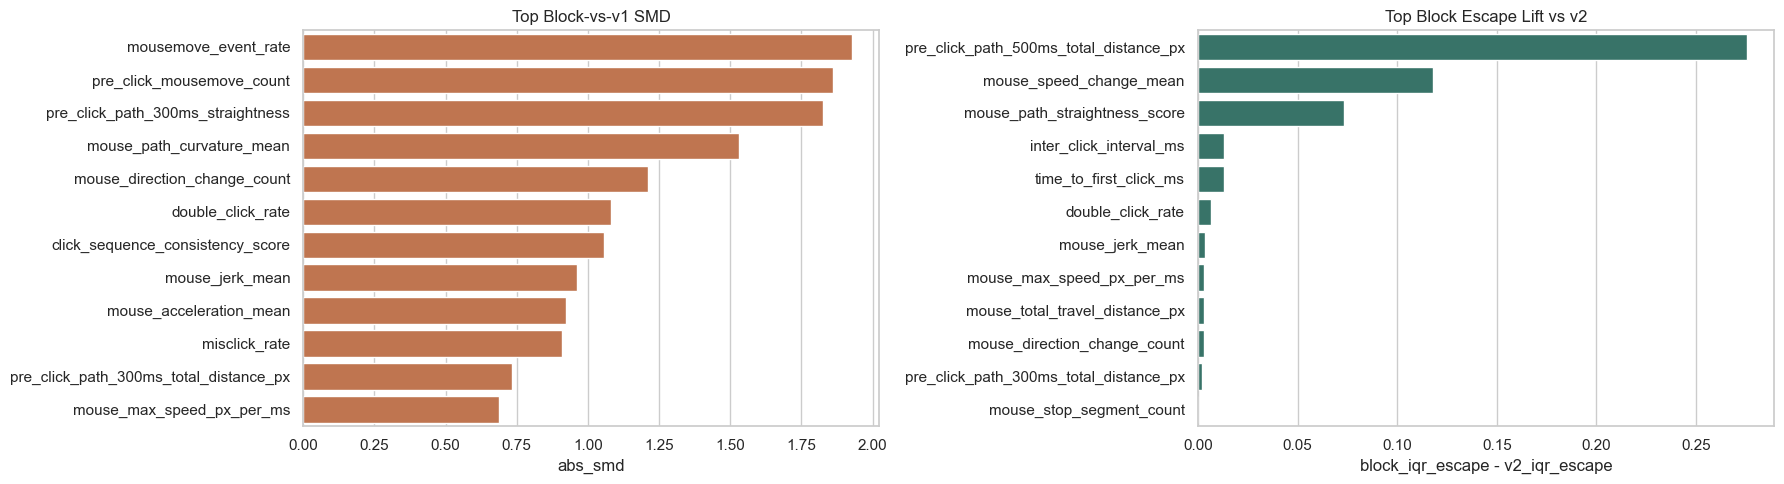

In [6]:
v2_shift_df = build_shift_df(v1_quality_df, v2_quality_df, "h1_v2_allow")
block_shift_df = build_shift_df(v1_quality_df, block_quality_df, "m1_v2_block")

v2_escape_df = compute_reference_escape(v1_df, v2_df, feature_cols, "h1_v2_allow")
block_escape_df = compute_reference_escape(v1_df, block_df, feature_cols, "m1_v2_block")

escape_compare_df = (
    v2_escape_df.merge(block_escape_df, on="feature", suffixes=("_v2", "_block"))
)
escape_compare_df["iqr_escape_lift_block_minus_v2"] = (
    escape_compare_df["iqr_escape_rate_block"] - escape_compare_df["iqr_escape_rate_v2"]
)
escape_compare_df["tail_escape_lift_block_minus_v2"] = (
    escape_compare_df["tail_escape_rate_block"] - escape_compare_df["tail_escape_rate_v2"]
)
escape_compare_df["robust_escape_lift_block_minus_v2"] = (
    escape_compare_df["robust_escape_rate_block"] - escape_compare_df["robust_escape_rate_v2"]
)

top_block_shift_df = block_shift_df.sort_values("abs_smd", ascending=False)[
    [
        "feature",
        "abs_smd",
        "null_ratio_ref",
        "null_ratio_target",
        "median_ref",
        "median_target",
        "abs_median_gap",
    ]
].head(TOP_K)

top_escape_lift_df = escape_compare_df.sort_values("iqr_escape_lift_block_minus_v2", ascending=False)[
    [
        "feature",
        "iqr_escape_rate_v2",
        "iqr_escape_rate_block",
        "iqr_escape_lift_block_minus_v2",
        "tail_escape_rate_v2",
        "tail_escape_rate_block",
    ]
].head(TOP_K)

print("block vs v1 기준 separability 가 큰 feature")
display(top_block_shift_df)

print("v1 기준 경계를 block 이 더 많이 벗어나는 feature")
display(top_escape_lift_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.barplot(data=top_block_shift_df, x="abs_smd", y="feature", ax=axes[0], color="#D16F3D")
axes[0].set_title("Top Block-vs-v1 SMD")
axes[0].set_xlabel("abs_smd")
axes[0].set_ylabel("")

sns.barplot(
    data=top_escape_lift_df,
    x="iqr_escape_lift_block_minus_v2",
    y="feature",
    ax=axes[1],
    color="#2E7D6E",
)
axes[1].set_title("Top Block Escape Lift vs v2")
axes[1].set_xlabel("block_iqr_escape - v2_iqr_escape")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

## 4. 3-way 구조 시각화

공통 feature 공간에서 세 데이터가 어느 정도 분리되는지 PCA 로 확인합니다.
`h1_v2_allow` 가 `h1_v1_allow` 근처에 남고, `m1_v2_block` 이 별도 영역으로 이동하면 threshold calibration 에 유리합니다.

Explained variance ratio: [0.99658362 0.00340915]


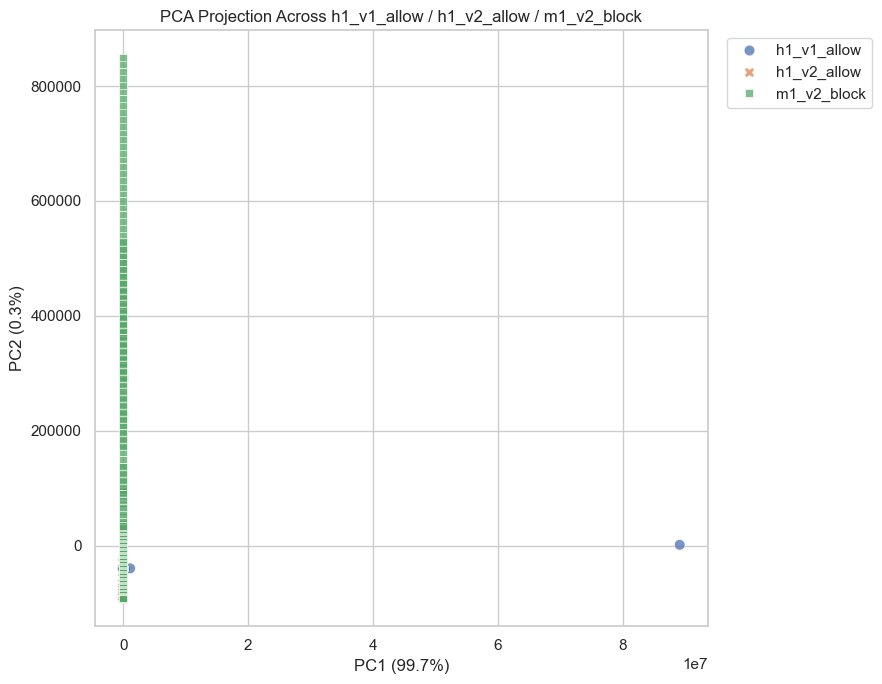

In [7]:
pca_feature_cols = [feature for feature in feature_cols if all_df[feature].notna().sum() > 0]
pca_imputer = SimpleImputer(strategy="median")
pca_input = pca_imputer.fit_transform(all_df[pca_feature_cols])
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(pca_input)

pca_df = all_df[["dataset", "role", "label", "trial_id"]].copy()
pca_df["pc1"] = pca_coords[:, 0]
pca_df["pc2"] = pca_coords[:, 1]

explained_ratio = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_ratio)

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_df,
    x="pc1",
    y="pc2",
    hue="dataset",
    style="dataset",
    alpha=0.75,
    s=60,
)
plt.title("PCA Projection Across h1_v1_allow / h1_v2_allow / m1_v2_block")
plt.xlabel(f"PC1 ({explained_ratio[0]:.1%})")
plt.ylabel(f"PC2 ({explained_ratio[1]:.1%})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. IsolationForest score 비교

현재 실험 노트북과 같은 형태로 `SimpleImputer(median, add_indicator=True) -> IsolationForest` 를 `h1_v1_allow` 에만 학습합니다.

여기서 중요 포인트:

- `train_all_nan_features`: train 에서 전부 NaN 이라 모델이 실제로 입력으로 못 쓰는 feature
- `h1_v2_allow` score: false positive 위험
- `m1_v2_block` score: separability 및 threshold calibration 신호

train_all_nan_features: ['click_offset_from_element_center_px', 'click_offset_variance_px', 'inter_element_move_interval_std_ms', 'time_from_element_clickable_to_click_ms', 'time_from_element_visible_to_click_ms']

fit warnings
- Skipping features without any observed values: ['click_offset_from_element_center_px' 'click_offset_variance_px'
 'inter_element_move_interval_std_ms'
 'time_from_element_clickable_to_click_ms'
 'time_from_element_visible_to_click_ms']. At least one non-missing value is needed for imputation with strategy='median'.


,dataset,rows,score_mean,score_median,score_p95,score_p99
0,h1_v1_allow,720,-0.141354,-0.152579,-0.049724,0.095292
1,h1_v2_allow,30,-0.119990,-0.146303,0.016096,0.074901
2,m1_v2_block,460,-0.010786,-0.049837,0.087738,0.087738



score warnings for h1_v1_allow
- Skipping features without any observed values: ['click_offset_from_element_center_px' 'click_offset_variance_px'
 'inter_element_move_interval_std_ms'
 'time_from_element_clickable_to_click_ms'
 'time_from_element_visible_to_click_ms']. At least one non-missing value is needed for imputation with strategy='median'.

score warnings for h1_v2_allow
- Skipping features without any observed values: ['click_offset_from_element_center_px' 'click_offset_variance_px'
 'inter_element_move_interval_std_ms'
 'time_from_element_clickable_to_click_ms'
 'time_from_element_visible_to_click_ms']. At least one non-missing value is needed for imputation with strategy='median'.

score warnings for m1_v2_block
- Skipping features without any observed values: ['click_offset_from_element_center_px' 'click_offset_variance_px'
 'inter_element_move_interval_std_ms'
 'time_from_element_clickable_to_click_ms'
 'time_from_element_visible_to_click_ms']. At least one non-missing va

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_37044\2885131775.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=score_plot_df, x="dataset", y="iforest_outlier_score", ax=axes[0], palette="Set2")


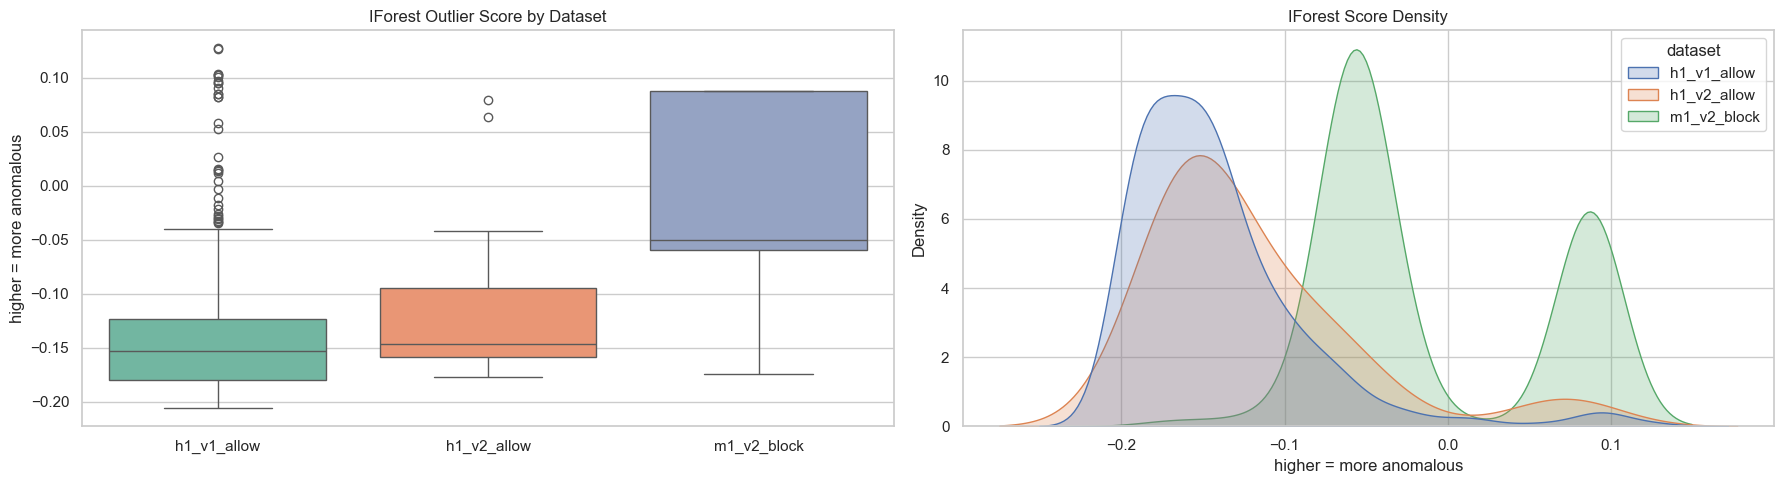

In [8]:
iforest_model, train_all_nan_features, fit_warning_messages = fit_iforest(v1_df, feature_cols, IFOREST_PARAMS)

print("train_all_nan_features:", train_all_nan_features)
if fit_warning_messages:
    print("\nfit warnings")
    for message in fit_warning_messages:
        print("-", message)

scored_by_dataset = {}
score_summary_rows = []
score_warning_map = {}
for alias, frame in dataset_frames.items():
    score_series, warning_messages = score_iforest(iforest_model, frame, feature_cols)
    scored_frame = frame.copy()
    scored_frame["iforest_outlier_score"] = score_series.values
    scored_by_dataset[alias] = scored_frame
    score_warning_map[alias] = warning_messages
    score_summary_rows.append(
        {
            "dataset": alias,
            "rows": len(scored_frame),
            "score_mean": float(scored_frame["iforest_outlier_score"].mean()),
            "score_median": float(scored_frame["iforest_outlier_score"].median()),
            "score_p95": float(scored_frame["iforest_outlier_score"].quantile(0.95)),
            "score_p99": float(scored_frame["iforest_outlier_score"].quantile(0.99)),
        }
    )

score_summary_df = pd.DataFrame(score_summary_rows)
display(score_summary_df)

for alias, warning_messages in score_warning_map.items():
    if warning_messages:
        print(f"\nscore warnings for {alias}")
        for message in warning_messages:
            print("-", message)

score_plot_df = pd.concat(
    [
        scored_by_dataset["h1_v1_allow"][["dataset", "iforest_outlier_score"]],
        scored_by_dataset["h1_v2_allow"][["dataset", "iforest_outlier_score"]],
        scored_by_dataset["m1_v2_block"][["dataset", "iforest_outlier_score"]],
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.boxplot(data=score_plot_df, x="dataset", y="iforest_outlier_score", ax=axes[0], palette="Set2")
axes[0].set_title("IForest Outlier Score by Dataset")
axes[0].set_xlabel("")
axes[0].set_ylabel("higher = more anomalous")

sns.kdeplot(
    data=score_plot_df,
    x="iforest_outlier_score",
    hue="dataset",
    common_norm=False,
    fill=True,
    alpha=0.25,
    ax=axes[1],
)
axes[1].set_title("IForest Score Density")
axes[1].set_xlabel("higher = more anomalous")
plt.tight_layout()
plt.show()

## 6. Threshold calibration

threshold calibration 은 다음 전제로 계산합니다.

- negative: `h1_v2_allow`
- positive: `m1_v2_block`

함께 `h1_v1_allow` score quantile 기반 threshold 도 비교해서,
train-human 기준선만으로 충분한지, 아니면 `m1_v2_block` 을 반영한 보정이 필요한지 확인합니다.

,threshold,tp,fn,fp,tn,precision,recall,f1
0,-0.051344,242,218,3,27,0.987755,0.526087,0.686525
1,-0.051029,238,222,3,27,0.987552,0.517391,0.679030
2,-0.050341,234,226,3,27,0.987342,0.508696,0.671449
3,-0.049819,230,230,3,27,0.987124,0.500000,0.663781
4,-0.049290,227,233,3,27,0.986957,0.493478,0.657971
5,-0.049010,221,239,3,27,0.986607,0.480435,0.646199
6,-0.047979,217,243,3,27,0.986364,0.471739,0.638235
7,-0.045880,213,247,3,27,0.986111,0.463043,0.630178
8,-0.044869,209,251,3,27,0.985849,0.454348,0.622024
9,-0.043711,205,255,3,27,0.985577,0.445652,0.613772


,policy,threshold,tp,fn,fp,tn,precision,recall,f1
0,v1_p95,-4.972412e-02,229.0,231.0,3.0,27.0,0.987069,0.497826,0.661850
1,v1_p97,-3.547510e-16,151.0,309.0,2.0,28.0,0.986928,0.328261,0.492659
2,v1_p99,9.529192e-02,0.0,460.0,0.0,30.0,NaN,0.000000,NaN
3,best_f1_from_v2_vs_block,-5.134367e-02,242.0,218.0,3.0,27.0,0.987755,0.526087,0.686525
4,precision>=0.95_max_recall,-5.134367e-02,242.0,218.0,3.0,27.0,0.987755,0.526087,0.686525
5,precision>=0.99_max_recall,7.258194e-02,148.0,312.0,1.0,29.0,0.993289,0.321739,0.486043


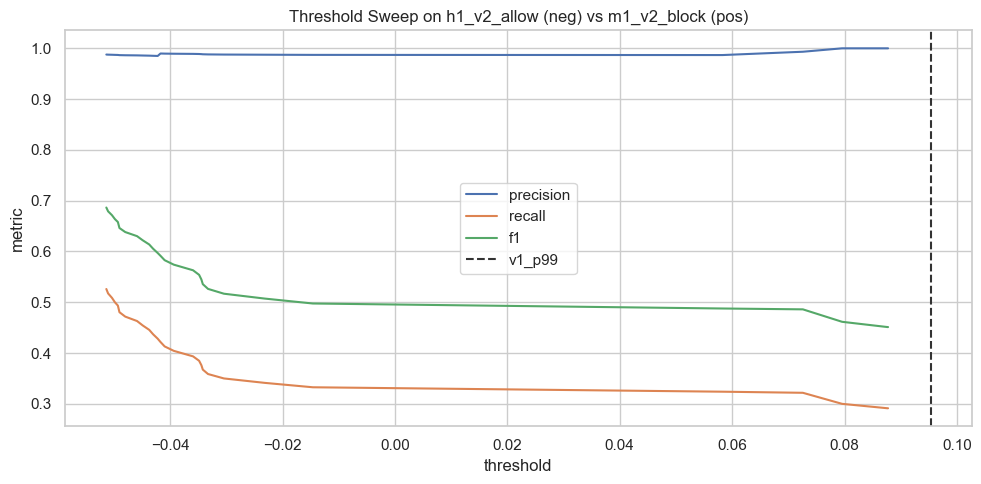

In [9]:
negative_scores = scored_by_dataset["h1_v2_allow"]["iforest_outlier_score"].to_numpy()
positive_scores = scored_by_dataset["m1_v2_block"]["iforest_outlier_score"].to_numpy()
train_scores = scored_by_dataset["h1_v1_allow"]["iforest_outlier_score"].to_numpy()

sweep_df = threshold_sweep(negative_scores, positive_scores)
display(sweep_df.head(12))

v1_quantile_thresholds = {
    "v1_p95": float(np.quantile(train_scores, 0.95)),
    "v1_p97": float(np.quantile(train_scores, 0.97)),
    "v1_p99": float(np.quantile(train_scores, 0.99)),
}

best_f1_row = sweep_df.iloc[0].to_dict()
precision95_df = sweep_df.loc[sweep_df["precision"] >= 0.95]
precision99_df = sweep_df.loc[sweep_df["precision"] >= 0.99]

threshold_candidate_rows = []
for policy_name, threshold in v1_quantile_thresholds.items():
    row = metrics_at_threshold(negative_scores, positive_scores, threshold)
    row["policy"] = policy_name
    threshold_candidate_rows.append(row)

best_f1_row["policy"] = "best_f1_from_v2_vs_block"
threshold_candidate_rows.append(best_f1_row)

if not precision95_df.empty:
    row = precision95_df.sort_values(["recall", "precision"], ascending=False).iloc[0].to_dict()
    row["policy"] = "precision>=0.95_max_recall"
    threshold_candidate_rows.append(row)

if not precision99_df.empty:
    row = precision99_df.sort_values(["recall", "precision"], ascending=False).iloc[0].to_dict()
    row["policy"] = "precision>=0.99_max_recall"
    threshold_candidate_rows.append(row)

threshold_candidate_df = pd.DataFrame(threshold_candidate_rows)[
    ["policy", "threshold", "tp", "fn", "fp", "tn", "precision", "recall", "f1"]
].drop_duplicates(subset=["policy"])

display(threshold_candidate_df)

sorted_curve_df = sweep_df.sort_values("threshold")
plt.figure(figsize=(10, 5))
plt.plot(sorted_curve_df["threshold"], sorted_curve_df["precision"], label="precision")
plt.plot(sorted_curve_df["threshold"], sorted_curve_df["recall"], label="recall")
plt.plot(sorted_curve_df["threshold"], sorted_curve_df["f1"], label="f1")
plt.axvline(v1_quantile_thresholds["v1_p99"], color="#333333", linestyle="--", label="v1_p99")
plt.title("Threshold Sweep on h1_v2_allow (neg) vs m1_v2_block (pos)")
plt.xlabel("threshold")
plt.ylabel("metric")
plt.legend()
plt.tight_layout()
plt.show()

## 7. FP / FN 점검

`precision>=0.95` 조건을 만족하는 threshold 중 recall 이 최대인 값을 우선 추천 threshold 로 보고,

- `h1_v2_allow` 에서 false positive 로 잡히는 trial
- `m1_v2_block` 에서 false negative 로 남는 trial

을 `h1_v1_allow` 기준 feature explanation 과 함께 확인합니다.

In [10]:
if not precision95_df.empty:
    recommended_row = precision95_df.sort_values(["recall", "precision"], ascending=False).iloc[0]
    recommendation_policy = "precision>=0.95_max_recall"
else:
    recommended_row = sweep_df.iloc[0]
    recommendation_policy = "fallback_best_f1"

recommended_threshold = float(recommended_row["threshold"])
print("recommendation_policy:", recommendation_policy)
print("recommended_threshold:", recommended_threshold)
print("recommended_metrics:", recommended_row[["precision", "recall", "f1", "tp", "fn", "fp", "tn"]].to_dict())

v2_fp_df = scored_by_dataset["h1_v2_allow"].loc[
    scored_by_dataset["h1_v2_allow"]["iforest_outlier_score"] >= recommended_threshold
].copy()
block_fn_df = scored_by_dataset["m1_v2_block"].loc[
    scored_by_dataset["m1_v2_block"]["iforest_outlier_score"] < recommended_threshold
].copy()

if not v2_fp_df.empty:
    v2_fp_df["reference_explanation"] = v2_fp_df.apply(
        lambda row: explain_trial_against_reference(row, v1_df, feature_cols, top_n=5),
        axis=1,
    )

if not block_fn_df.empty:
    block_fn_df["reference_explanation"] = block_fn_df.apply(
        lambda row: explain_trial_against_reference(row, v1_df, feature_cols, top_n=5),
        axis=1,
    )

print("h1_v2_allow false positives")
display(
    v2_fp_df.sort_values("iforest_outlier_score", ascending=False)[
        ["trial_id", "iforest_outlier_score", "reference_explanation", "path"]
    ].head(15)
)

print("m1_v2_block false negatives")
display(
    block_fn_df.sort_values("iforest_outlier_score", ascending=True)[
        ["trial_id", "iforest_outlier_score", "reference_explanation", "path"]
    ].head(15)
)

recommendation_policy: precision>=0.95_max_recall
recommended_threshold: -0.051343665841298236
recommended_metrics: {'precision': 0.9877551020408163, 'recall': 0.5260869565217391, 'f1': 0.6865248226950355, 'tp': 242.0, 'fn': 218.0, 'fp': 3.0, 'tn': 27.0}
h1_v2_allow false positives


,trial_id,iforest_outlier_score,reference_explanation,path
6,696,0.079455,pre_click_path_500ms_straightness=0 (ref_med=0...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
26,716,0.063751,pre_click_path_500ms_straightness=0 (ref_med=0...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
11,701,-0.042149,mouse_avg_speed_px_per_ms=0.9811 (ref_med=0.22...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...


m1_v2_block false negatives


,trial_id,iforest_outlier_score,reference_explanation,path
1,752,-0.174524,mouse_path_curvature_mean=0.1635 (ref_med=0.09...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
11,762,-0.171851,pre_click_path_500ms_total_distance_px=269 (re...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
2,753,-0.160218,"mouse_direction_change_count=33 (ref_med=14, d...",c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
10,761,-0.155933,pre_click_path_300ms_straightness=0 (ref_med=0...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
12,763,-0.132918,mouse_path_curvature_mean=0.3279 (ref_med=0.09...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
41,792,-0.132514,pre_click_path_500ms_straightness=0 (ref_med=0...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
8,759,-0.119605,"time_to_first_click_ms=8840 (ref_med=2008, dis...",c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
5,756,-0.113968,time_to_first_click_ms=2.342e+04 (ref_med=2008...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
28,779,-0.105159,"mousemove_event_rate=0.8589 (ref_med=7.506, di...",c:\Users\SSAFY\Desktop\ai-macro-detection\serv...
9,760,-0.102373,mouse_avg_speed_px_per_ms=0.5515 (ref_med=0.22...,c:\Users\SSAFY\Desktop\ai-macro-detection\serv...


## 8. 분석 리포트

마지막 셀은 바로 의사결정에 쓰기 위한 요약입니다.

In [11]:
top_train_gap_features = train_all_nan_observed_later_df["feature"].head(5).tolist()
top_block_shift_features = block_shift_df.sort_values("abs_smd", ascending=False)["feature"].head(5).tolist()
top_block_escape_features = escape_compare_df.sort_values(
    "iqr_escape_lift_block_minus_v2", ascending=False
)["feature"].head(5).tolist()

report_lines = []
report_lines.append("핵심 요약")
report_lines.append(
    f"- rows: h1_v1_allow={len(v1_df)}, h1_v2_allow={len(v2_df)}, m1_v2_block={len(block_df)}"
)
report_lines.append(
    f"- train(h1_v1) all-NaN but later observed features: {top_train_gap_features if top_train_gap_features else '없음'}"
)
report_lines.append(
    f"- block separability top features(abs_smd): {top_block_shift_features if top_block_shift_features else '없음'}"
)
report_lines.append(
    f"- v1 기준 경계를 block 이 더 자주 벗어나는 top features: {top_block_escape_features if top_block_escape_features else '없음'}"
)
report_lines.append(
    f"- recommended threshold policy={recommendation_policy}, threshold={recommended_threshold:.6f}, "
    f"precision={recommended_row['precision']:.3f}, recall={recommended_row['recall']:.3f}, f1={recommended_row['f1']:.3f}"
)
report_lines.append(
    f"- false positives on h1_v2_allow={len(v2_fp_df)}, false negatives on m1_v2_block={len(block_fn_df)}"
)

print("\n".join(report_lines))

핵심 요약
- rows: h1_v1_allow=720, h1_v2_allow=30, m1_v2_block=460
- train(h1_v1) all-NaN but later observed features: ['click_offset_from_element_center_px', 'time_from_element_clickable_to_click_ms', 'time_from_element_visible_to_click_ms', 'click_offset_variance_px', 'inter_element_move_interval_std_ms']
- block separability top features(abs_smd): ['mousemove_event_rate', 'pre_click_mousemove_count', 'pre_click_path_300ms_straightness', 'mouse_path_curvature_mean', 'mouse_direction_change_count']
- v1 기준 경계를 block 이 더 자주 벗어나는 top features: ['pre_click_path_500ms_total_distance_px', 'mouse_speed_change_mean', 'mouse_path_straightness_score', 'inter_click_interval_ms', 'time_to_first_click_ms']
- recommended threshold policy=precision>=0.95_max_recall, threshold=-0.051344, precision=0.988, recall=0.526, f1=0.687
- false positives on h1_v2_allow=3, false negatives on m1_v2_block=218
